In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [16]:
training = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")

In [17]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
def preprocess(df):
  #family size
  df['Family'] = df['SibSp']+df['Parch']

  #filling the missing/null values

  df['Age'] = df['Age'].fillna(df['Age'].median())#for age

  df['Fare'] = df['Fare'].fillna(df['Fare'].median())#for Fare

  df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])#for embarked

  Sex = pd.get_dummies(df['Sex'],prefix = 'Sex',drop_first= True,dtype = int)
  # drop_sex = df.drop('Sex',axis =1 ,errors = 'Ignore')
  df = pd.concat([Sex,df ], axis =1)

  #drop some
  drop_values = ['Name','PassengerId','Ticket','Cabin','SibSp','Parch','Sex']
  df = df.drop(drop_values,axis =1)

  #one-hot encoding
  embarked = pd.get_dummies(df['Embarked'],prefix = 'Embarked',drop_first=True,dtype =int)
  drop_embark = df.drop('Embarked',axis =1 ,errors ='Ignore')
  df = pd.concat([embarked,drop_embark],axis =1)

  return df

In [19]:
training = preprocess(training)
test = preprocess(test)


In [20]:
print(training.columns.tolist())
print(test.columns.tolist())

['Embarked_Q', 'Embarked_S', 'Sex_male', 'Survived', 'Pclass', 'Age', 'Fare', 'Family']
['Embarked_Q', 'Embarked_S', 'Sex_male', 'Pclass', 'Age', 'Fare', 'Family']


In [21]:
print(training['Sex_male'])
print(test['Sex_male'])

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex_male, Length: 891, dtype: int64
0      1
1      0
2      1
3      1
4      0
      ..
413    1
414    0
415    1
416    1
417    1
Name: Sex_male, Length: 418, dtype: int64


In [22]:
X = training.drop('Survived',axis = 1)
y = training['Survived']

X_test = test

In [23]:
model = RandomForestClassifier(random_state= 1)
model.fit(X,y)

pred = model.predict(X_test)

In [24]:
passenger_ids = pd.read_csv('test.csv')['PassengerId']
output = pd.DataFrame({'PassengerId':passenger_ids,'Survived' : pred})
output.to_csv('Submission.csv',index =False)

In [25]:
from sklearn.model_selection import cross_val_score
cross_val_score(model,X,y,cv=3)

array([0.75084175, 0.83164983, 0.7979798 ])

In [26]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(model,X,y,cv=3)
y_pred

array([0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,

In [27]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y,y_pred)

array([[462,  87],
       [ 97, 245]])

In [28]:
from sklearn.metrics import precision_score
precision_score(y,y_pred)

0.7379518072289156

In [29]:
from sklearn.metrics import recall_score
recall_score(y,y_pred)

0.716374269005848

In [30]:
from sklearn.metrics import f1_score
f1_score(y,y_pred)

0.7270029673590505

In [31]:
y_score= cross_val_predict(model,X,y,cv=3,method ="predict_proba")

PRECISION/RECALL TRADEOFF

In [32]:
from sklearn.metrics import precision_recall_curve
precision,recall,threshold=precision_recall_curve(y,y_score[:,1])

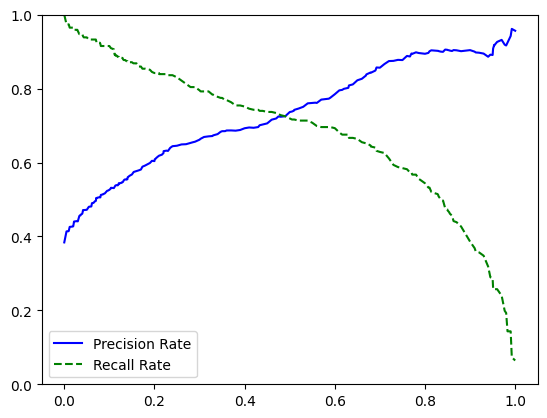

In [33]:
import matplotlib.pyplot as plt
def precision_vs_recall_vs_threshold(precision,recall,threshold):
  plt.plot(threshold,precision[:-1],'b-',label='Precision Rate')
  plt.plot(threshold,recall[:-1],'g--',label='Recall Rate')
  plt.legend(loc="best")
  plt.ylim(0,1)
precision_vs_recall_vs_threshold(precision,recall,threshold)
plt.show()

In [34]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y,y_score[:,1])

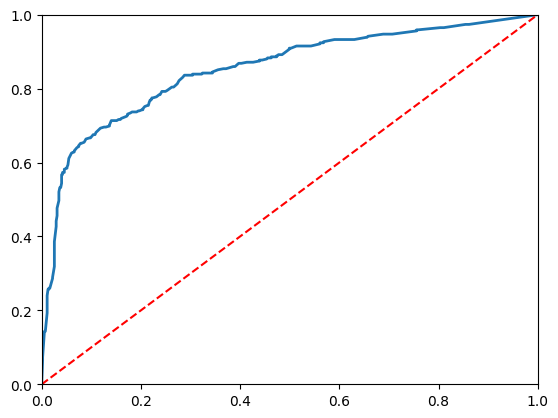

In [47]:
def roc_plot(fpr,tpr,label=None):
  plt.plot(fpr,tpr,linewidth=2,label=label)
  plt.plot([0,1],[0,1],'r--')
  plt.axis([0,1,0,1])
  plt.xlabel="FalsePositiveRate"
  plt.ylabel="TruePositiveRate"
roc_plot(fpr,tpr)
plt.show()

In [44]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y,y_score[:,1])

np.float64(0.8515349545691796)

THRESHOLD TUNING

In [51]:
y_score = cross_val_predict(model,X,y,cv=3,method="predict_proba")

In [55]:
threshold = 0.2
y_pred = (y_score>=threshold)



In [56]:
print(precision_score(y,y_pred[:,1]))
print(recall_score(y,y_pred[:,1]))

0.6037735849056604
0.8421052631578947
